In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

In [3]:
df = pd.read_csv("test2.csv")

print(df.shape)
df.head()

(515, 11)


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd,Label
0,2.195592,1419.207259,11.841909,26,3116,11.841909,0,26,547,26,ATTACK
1,2.193235,465.978355,7.295160,16,1022,7.295160,0,16,253,16,ATTACK
2,4.287880,1262.162274,10.727913,46,5412,10.727913,0,46,547,46,ATTACK
3,4.253776,384.599443,5.642046,24,1636,5.642046,0,24,251,24,ATTACK
4,2.096721,314.777226,5.246287,11,660,5.246287,0,11,252,11,ATTACK


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Flow Duration                515 non-null    float64
 1   Flow Bytes/s                 515 non-null    float64
 2   Flow Packets/s               515 non-null    float64
 3   Total Fwd Packets            515 non-null    int64  
 4   Total Length of Fwd Packets  515 non-null    int64  
 5   Fwd Packets/s                515 non-null    float64
 6   SYN Flag Count               515 non-null    int64  
 7   ACK Flag Count               515 non-null    int64  
 8   Init_Win_bytes_forward       515 non-null    int64  
 9   act_data_pkt_fwd             515 non-null    int64  
 10  Label                        515 non-null    object 
dtypes: float64(4), int64(6), object(1)
memory usage: 44.4+ KB
None


In [5]:
df.isnull().sum()

Flow Duration                  0
Flow Bytes/s                   0
Flow Packets/s                 0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packets/s                  0
SYN Flag Count                 0
ACK Flag Count                 0
Init_Win_bytes_forward         0
act_data_pkt_fwd               0
Label                          0
dtype: int64

In [6]:
print(df.duplicated().sum())

0


In [7]:
df["Label"].value_counts()

Label
ATTACK    515
Name: count, dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,515.0,3.374114,1.386441,0.009115,2.625412,3.875749,4.475152,4.996357
Flow Bytes/s,515.0,5956.044147,26971.099810,48.021403,195.868184,270.023258,394.841474,222435.561109
Flow Packets/s,515.0,12.461643,35.329617,0.648938,2.888744,4.050148,5.845238,438.849490
Total Fwd Packets,515.0,35.718447,97.487944,3.000000,7.000000,13.000000,19.500000,750.000000
Total Length of Fwd Packets,515.0,21541.438835,106406.497400,174.000000,466.000000,866.000000,1320.000000,871188.000000
Fwd Packets/s,515.0,12.461643,35.329617,0.648938,2.888744,4.050148,5.845238,438.849490
SYN Flag Count,515.0,19.739806,97.419398,0.000000,0.000000,0.000000,0.000000,750.000000
ACK Flag Count,515.0,16.256311,21.609380,0.000000,6.000000,12.000000,18.000000,172.000000
Init_Win_bytes_forward,515.0,45611.033010,22119.902997,250.000000,53248.000000,53248.000000,53248.000000,65535.000000
act_data_pkt_fwd,515.0,25.598058,99.607926,0.000000,0.000000,0.000000,0.000000,750.000000


In [9]:
df.median(numeric_only=True)

Flow Duration                      3.875749
Flow Bytes/s                     270.023258
Flow Packets/s                     4.050148
Total Fwd Packets                 13.000000
Total Length of Fwd Packets      866.000000
Fwd Packets/s                      4.050148
SYN Flag Count                     0.000000
ACK Flag Count                    12.000000
Init_Win_bytes_forward         53248.000000
act_data_pkt_fwd                   0.000000
dtype: float64

In [10]:
features = [
'Flow Duration',
'Flow Bytes/s',
'Flow Packets/s',
'Total Fwd Packets',
'Total Length of Fwd Packets',
'Fwd Packets/s',
'SYN Flag Count',
'ACK Flag Count',
'Init_Win_bytes_forward',
'act_data_pkt_fwd'
]

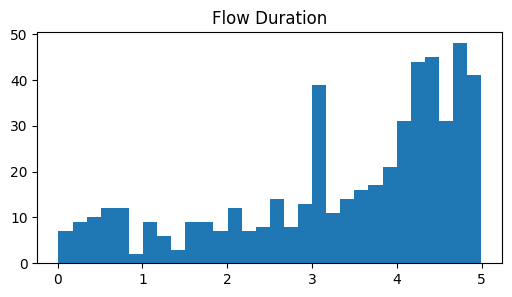

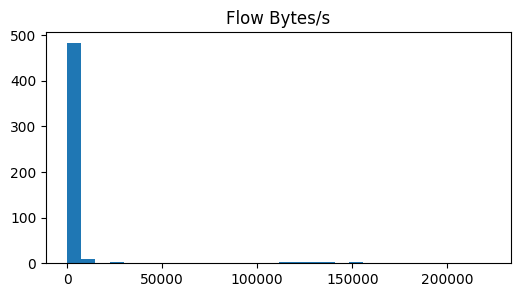

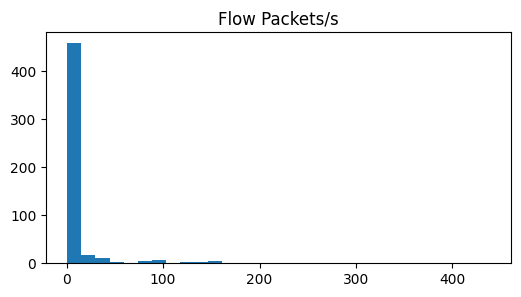

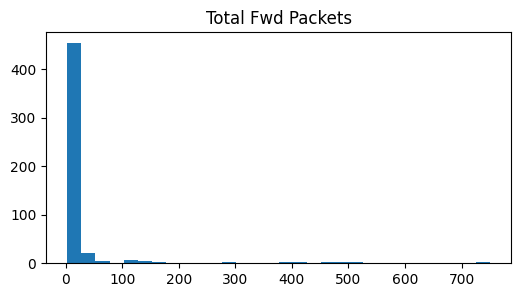

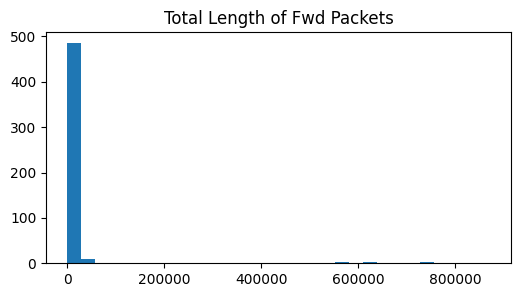

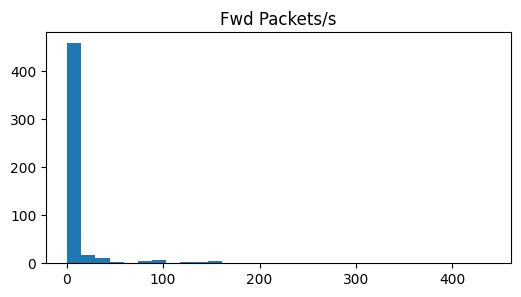

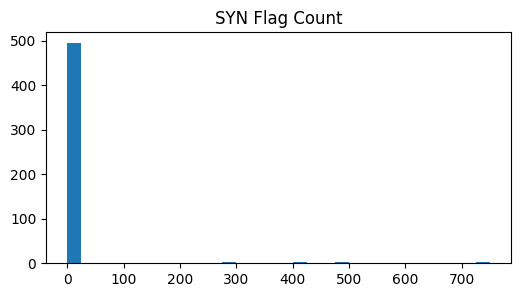

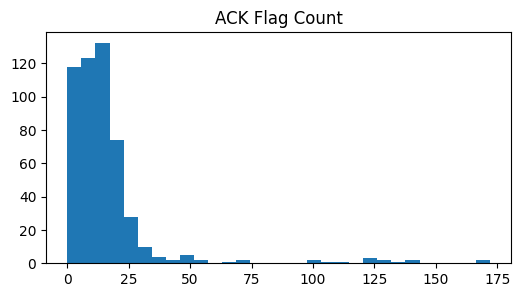

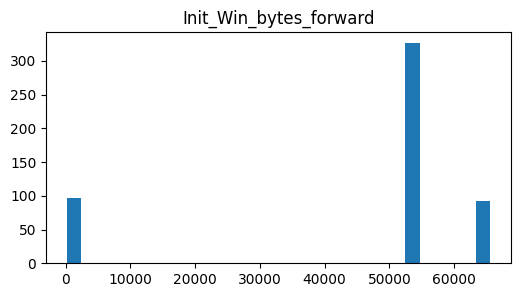

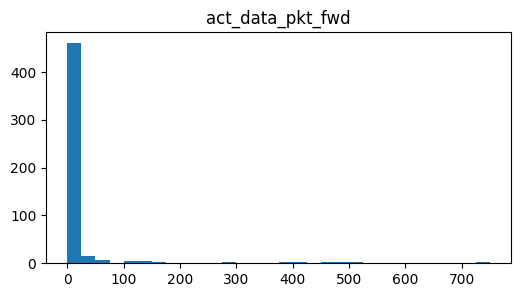

In [11]:
for col in features:

    plt.figure(figsize=(6,3))

    plt.hist(df[col], bins=30)

    plt.title(col)

    plt.show()

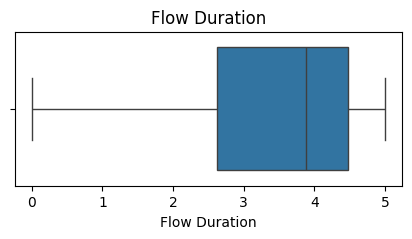

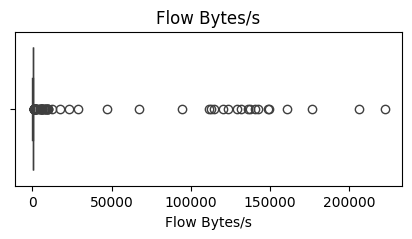

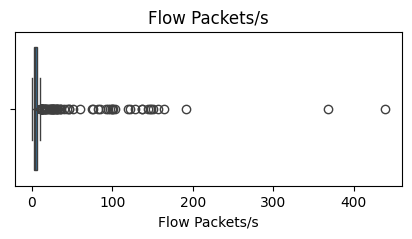

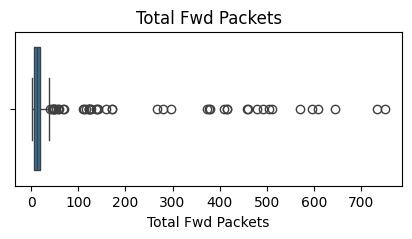

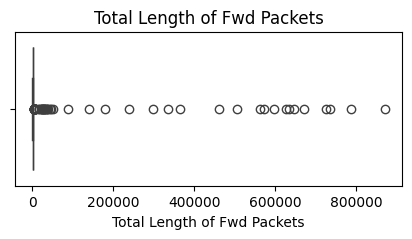

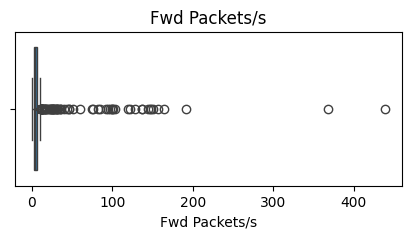

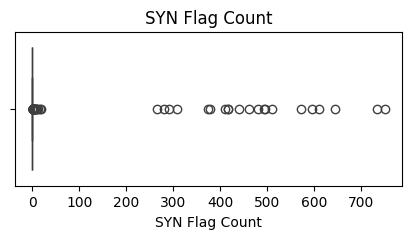

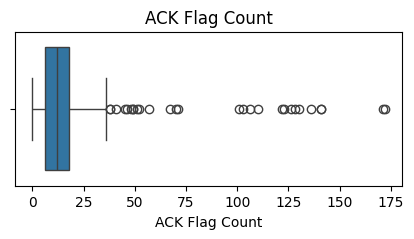

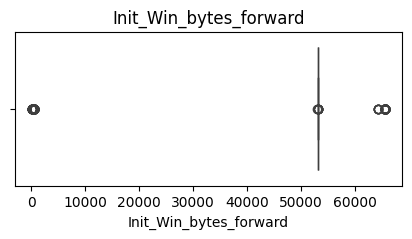

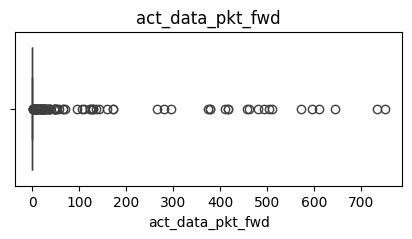

In [12]:
for col in features:

    plt.figure(figsize=(5,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

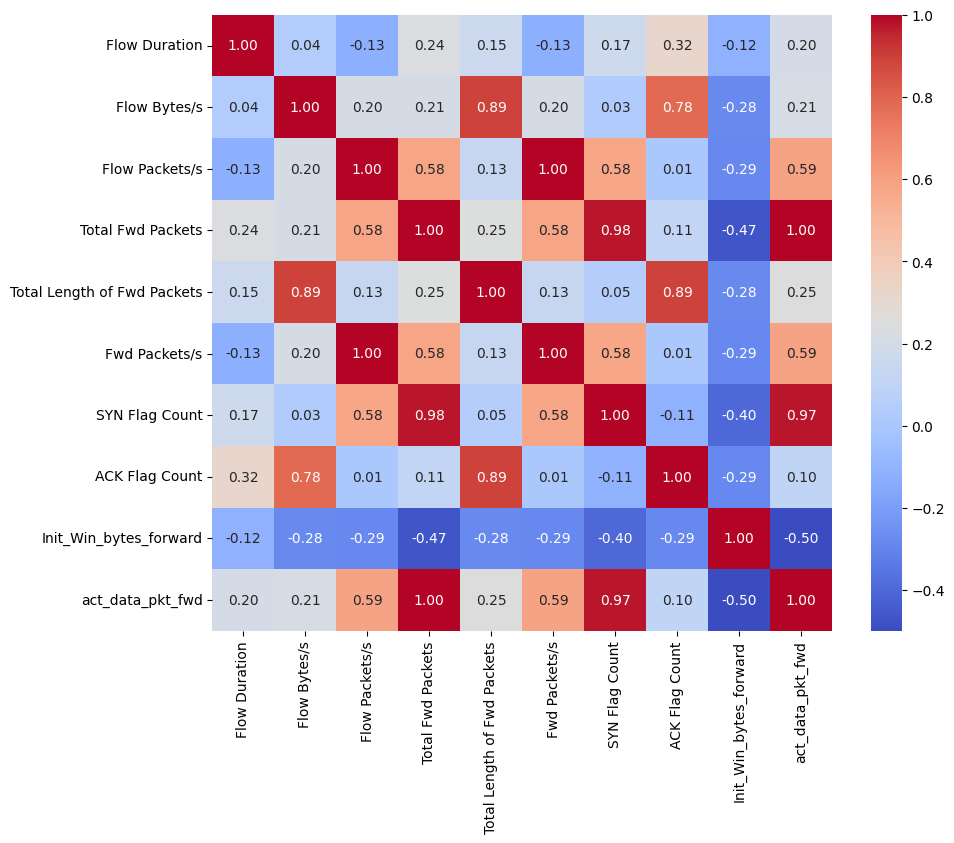

In [13]:
corr = df[features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [14]:
df[features].var().sort_values()

Flow Duration                  1.922218e+00
ACK Flag Count                 4.669653e+02
Flow Packets/s                 1.248182e+03
Fwd Packets/s                  1.248182e+03
SYN Flag Count                 9.490539e+03
Total Fwd Packets              9.503899e+03
act_data_pkt_fwd               9.921739e+03
Init_Win_bytes_forward         4.892901e+08
Flow Bytes/s                   7.274402e+08
Total Length of Fwd Packets    1.132234e+10
dtype: float64

In [15]:
for col in features:

    print(col)

    print(df[col].nunique())

Flow Duration
515
Flow Bytes/s
515
Flow Packets/s
515
Total Fwd Packets
76
Total Length of Fwd Packets
202
Fwd Packets/s
515
SYN Flag Count
30
ACK Flag Count
59
Init_Win_bytes_forward
15
act_data_pkt_fwd
72


In [16]:
for col in features:

    counts = df[col].value_counts()

    e = entropy(counts)

    print(col, e)

Flow Duration 6.244166900663737
Flow Bytes/s 6.244166900663737
Flow Packets/s 6.244166900663737
Total Fwd Packets 3.5290807266762045
Total Length of Fwd Packets 4.668854576785727
Fwd Packets/s 6.244166900663737
SYN Flag Count 1.0093805849344781
ACK Flag Count 3.4212974281879474
Init_Win_bytes_forward 1.3807328696659154
act_data_pkt_fwd 1.388135829603427


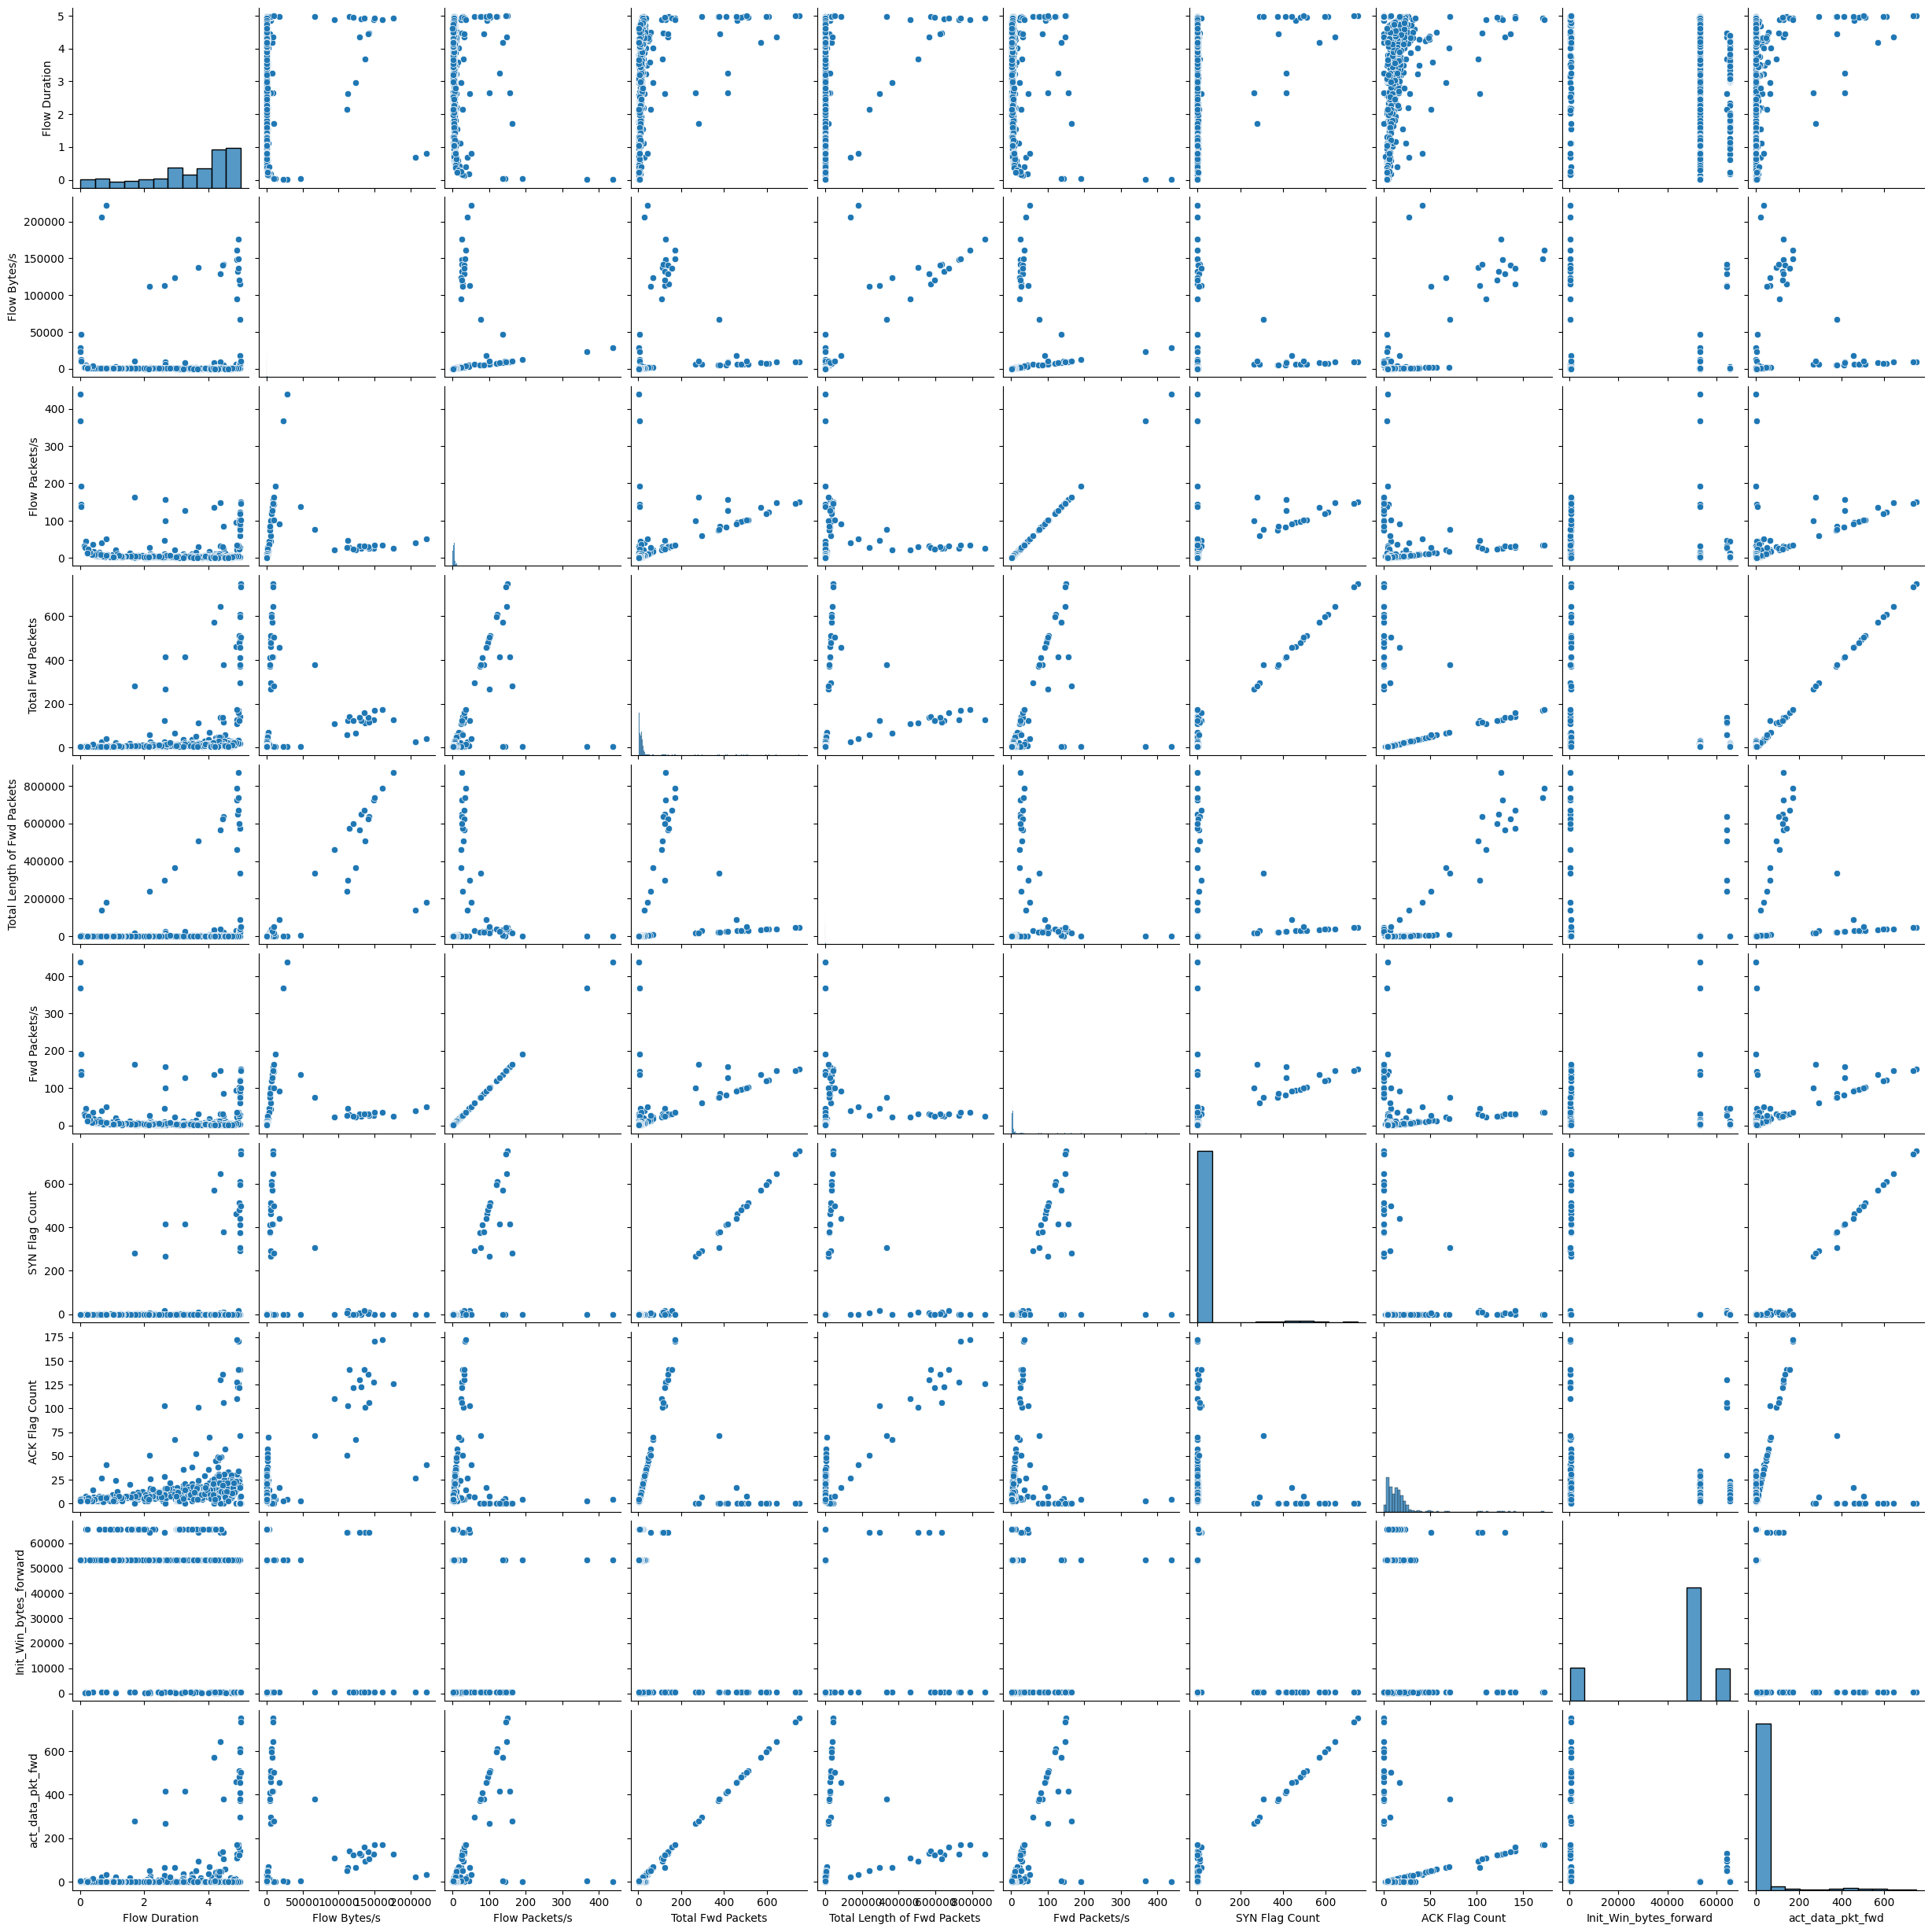

In [17]:
sns.pairplot(
    df[features]
)

In [18]:
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [19]:
X = df[features]

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

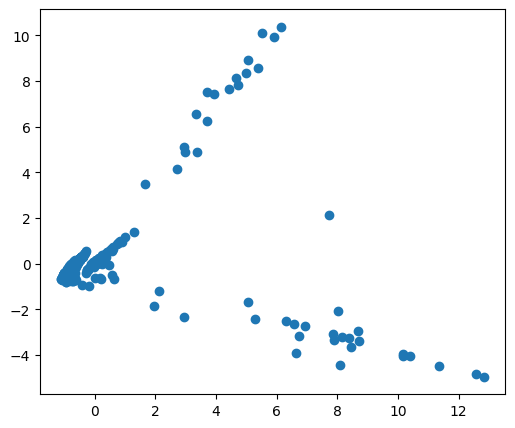

In [20]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.show()

In [21]:
corr = abs(df[features].corr())

corr

,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd
Flow Duration,1.000000,0.038720,0.129452,0.237907,0.151981,0.129452,0.166200,0.319792,0.117402,0.198854
Flow Bytes/s,0.038720,1.000000,0.204676,0.208013,0.891286,0.204676,0.033392,0.784378,0.277925,0.213599
Flow Packets/s,0.129452,0.204676,1.000000,0.581349,0.130644,1.000000,0.578068,0.008610,0.287123,0.587426
Total Fwd Packets,0.237907,0.208013,0.581349,1.000000,0.246919,0.581349,0.975045,0.111575,0.466661,0.996911
Total Length of Fwd Packets,0.151981,0.891286,0.130644,0.246919,1.000000,0.130644,0.048785,0.891438,0.280287,0.253377
Fwd Packets/s,0.129452,0.204676,1.000000,0.581349,0.130644,1.000000,0.578068,0.008610,0.287123,0.587426
SYN Flag Count,0.166200,0.033392,0.578068,0.975045,0.048785,0.578068,1.000000,0.111647,0.400731,0.974322
ACK Flag Count,0.319792,0.784378,0.008610,0.111575,0.891438,0.008610,0.111647,1.000000,0.285709,0.101672
Init_Win_bytes_forward,0.117402,0.277925,0.287123,0.466661,0.280287,0.287123,0.400731,0.285709,1.000000,0.498651
act_data_pkt_fwd,0.198854,0.213599,0.587426,0.996911,0.253377,0.587426,0.974322,0.101672,0.498651,1.000000


In [22]:
for col in features:

    print(
        col,
        df[col].std()
    )

Flow Duration 1.3864408599307245
Flow Bytes/s 26971.099809886793
Flow Packets/s 35.32961662219119
Total Fwd Packets 97.48794372987633
Total Length of Fwd Packets 106406.49739961249
Fwd Packets/s 35.32961662219119
SYN Flag Count 97.41939833097126
ACK Flag Count 21.60938003341563
Init_Win_bytes_forward 22119.902997164492
act_data_pkt_fwd 99.60792592323223
